# Лабораторная работа №2: Виртуальный датчик для контроля процесса обжига в печи

## Постановка задачи

Необходимо построить **виртуальный датчик** — регрессионную модель, которая по текущим и историческим показаниям 16 датчиков телеметрии предсказывает концентрацию целевого продукта (обычно измеряется лабораторно с задержкой 10–15 минут).  

Это позволит оператору получать оценку ключевого показателя качества **в реальном времени**, не дожидаясь результатов лабораторного анализа.

---
### Структура данных
| Файл | Описание |
|---|---|
| `data_train.csv` | Минутная телеметрия 16 датчиков, ~8 месяцев (~319k строк) |
| `target_train.csv` | Нерегулярные лабораторные замеры целевого показателя (~1773 строки) |
| `data_test_small.csv` | Телеметрия тестового периода (~39k строк) |


In [36]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.model_selection import TimeSeriesSplit

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 12})
sns.set_palette('husl')
SEED = 42

In [37]:
def _safe_datetime_index_like(x):
    """Вернуть DatetimeIndex, если это возможно, иначе None."""
    try:
        idx = pd.to_datetime(x, errors='coerce')
        if getattr(idx, 'notna', None) is not None:
            ok = idx.notna()
            if hasattr(ok, 'all') and ok.all():
                return pd.DatetimeIndex(idx)
        return None
    except Exception:
        return None

---
## 2.1 Разведочный анализ данных (EDA)

### 2.1.1 Загрузка данных

In [38]:
DATA_CANDIDATES = [
    Path('/Users/maksimtimosuk/Downloads'),
    Path.cwd(),
    Path('/mnt/data'),
    Path('.')
]

for candidate in DATA_CANDIDATES:
    train_path = candidate / 'data_train.csv'
    target_path = candidate / 'target_train.csv'
    test_path = candidate / 'data_test_small.csv'
    if train_path.exists() and target_path.exists() and test_path.exists():
        DATA_DIR = candidate
        break
else:
    raise FileNotFoundError('Не найдены data_train.csv, target_train.csv и data_test_small.csv')

data_train = pd.read_csv(DATA_DIR / 'data_train.csv', parse_dates=['datetime'])
target_train = pd.read_csv(DATA_DIR / 'target_train.csv', parse_dates=['Дата'])
data_test = pd.read_csv(DATA_DIR / 'data_test_small.csv', parse_dates=['datetime'])

target_train = target_train.rename(columns={'Дата': 'datetime'})

data_train = data_train.sort_values('datetime').drop_duplicates('datetime').set_index('datetime')
target_train = target_train.sort_values('datetime').drop_duplicates('datetime').set_index('datetime')
data_test = data_test.sort_values('datetime').drop_duplicates('datetime').set_index('datetime')

print(f'DATA_DIR = {DATA_DIR}')
print(f'data_train:   {data_train.shape}')
print(f'target_train: {target_train.shape}')
print(f'data_test:    {data_test.shape}')

DATA_DIR = /Users/maksimtimosuk/Downloads
data_train:   (317998, 16)
target_train: (1773, 1)
data_test:    (39747, 16)


In [39]:
missing = (data_train.isnull().mean() * 100).round(1)
pd.DataFrame({'missing_%': missing})

,missing_%
telemetry_0,0.0
telemetry_1,0.0
telemetry_2,0.0
telemetry_3,0.0
telemetry_4,0.0
telemetry_5,0.0
telemetry_6,0.0
telemetry_7,0.0
telemetry_8,0.0
telemetry_9,0.0


In [40]:
data_train.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
telemetry_0,317981.0,0.610,0.276,0.003,0.688,0.739,0.768,1.000
telemetry_1,317982.0,0.380,0.198,0.000,0.431,0.486,0.494,0.611
telemetry_2,317982.0,0.267,0.088,0.032,0.286,0.296,0.305,1.000
telemetry_3,317982.0,0.520,0.259,0.000,0.617,0.639,0.658,1.000
telemetry_4,317865.0,0.762,0.326,0.000,0.919,0.919,0.919,1.000
telemetry_5,317981.0,0.696,0.284,0.000,0.717,0.830,0.863,1.000
telemetry_6,317982.0,0.594,0.300,0.000,0.701,0.749,0.759,1.000
telemetry_7,317982.0,0.523,0.253,0.021,0.366,0.411,0.492,1.000
telemetry_8,317982.0,0.470,0.024,0.344,0.454,0.468,0.482,1.000
telemetry_9,317982.0,0.536,0.255,0.000,0.391,0.582,0.729,1.000


### 2.1.2 Визуальный анализ телеметрии

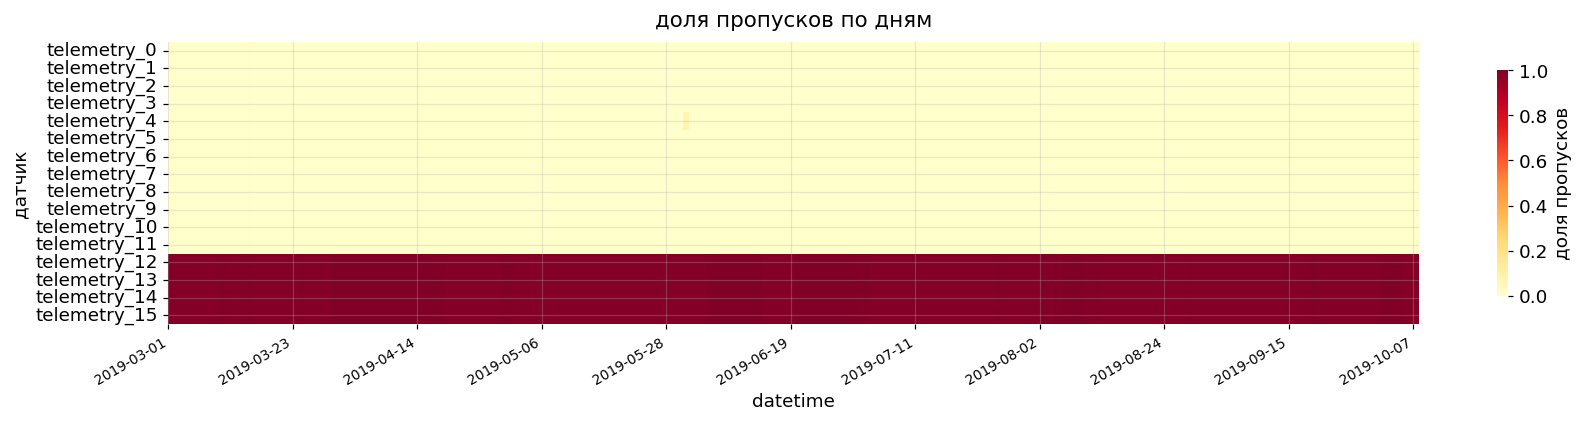

In [41]:
daily_null = data_train.isnull().resample('D').mean()

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    daily_null.T, cmap='YlOrRd', ax=ax,
    cbar_kws={'label': 'доля пропусков', 'shrink': 0.8},
    linewidths=0
)
ax.set_title('доля пропусков по дням', fontsize=14, pad=10)
ax.set_ylabel('датчик', fontsize=12)
n_ticks = len(daily_null)
step = max(1, n_ticks // 10)
ax.set_xticks(range(0, n_ticks, step))
ax.set_xticklabels(
    [str(daily_null.index[i].date()) for i in range(0, n_ticks, step)],
    rotation=30, ha='right', fontsize=9
)
plt.tight_layout()
plt.show()

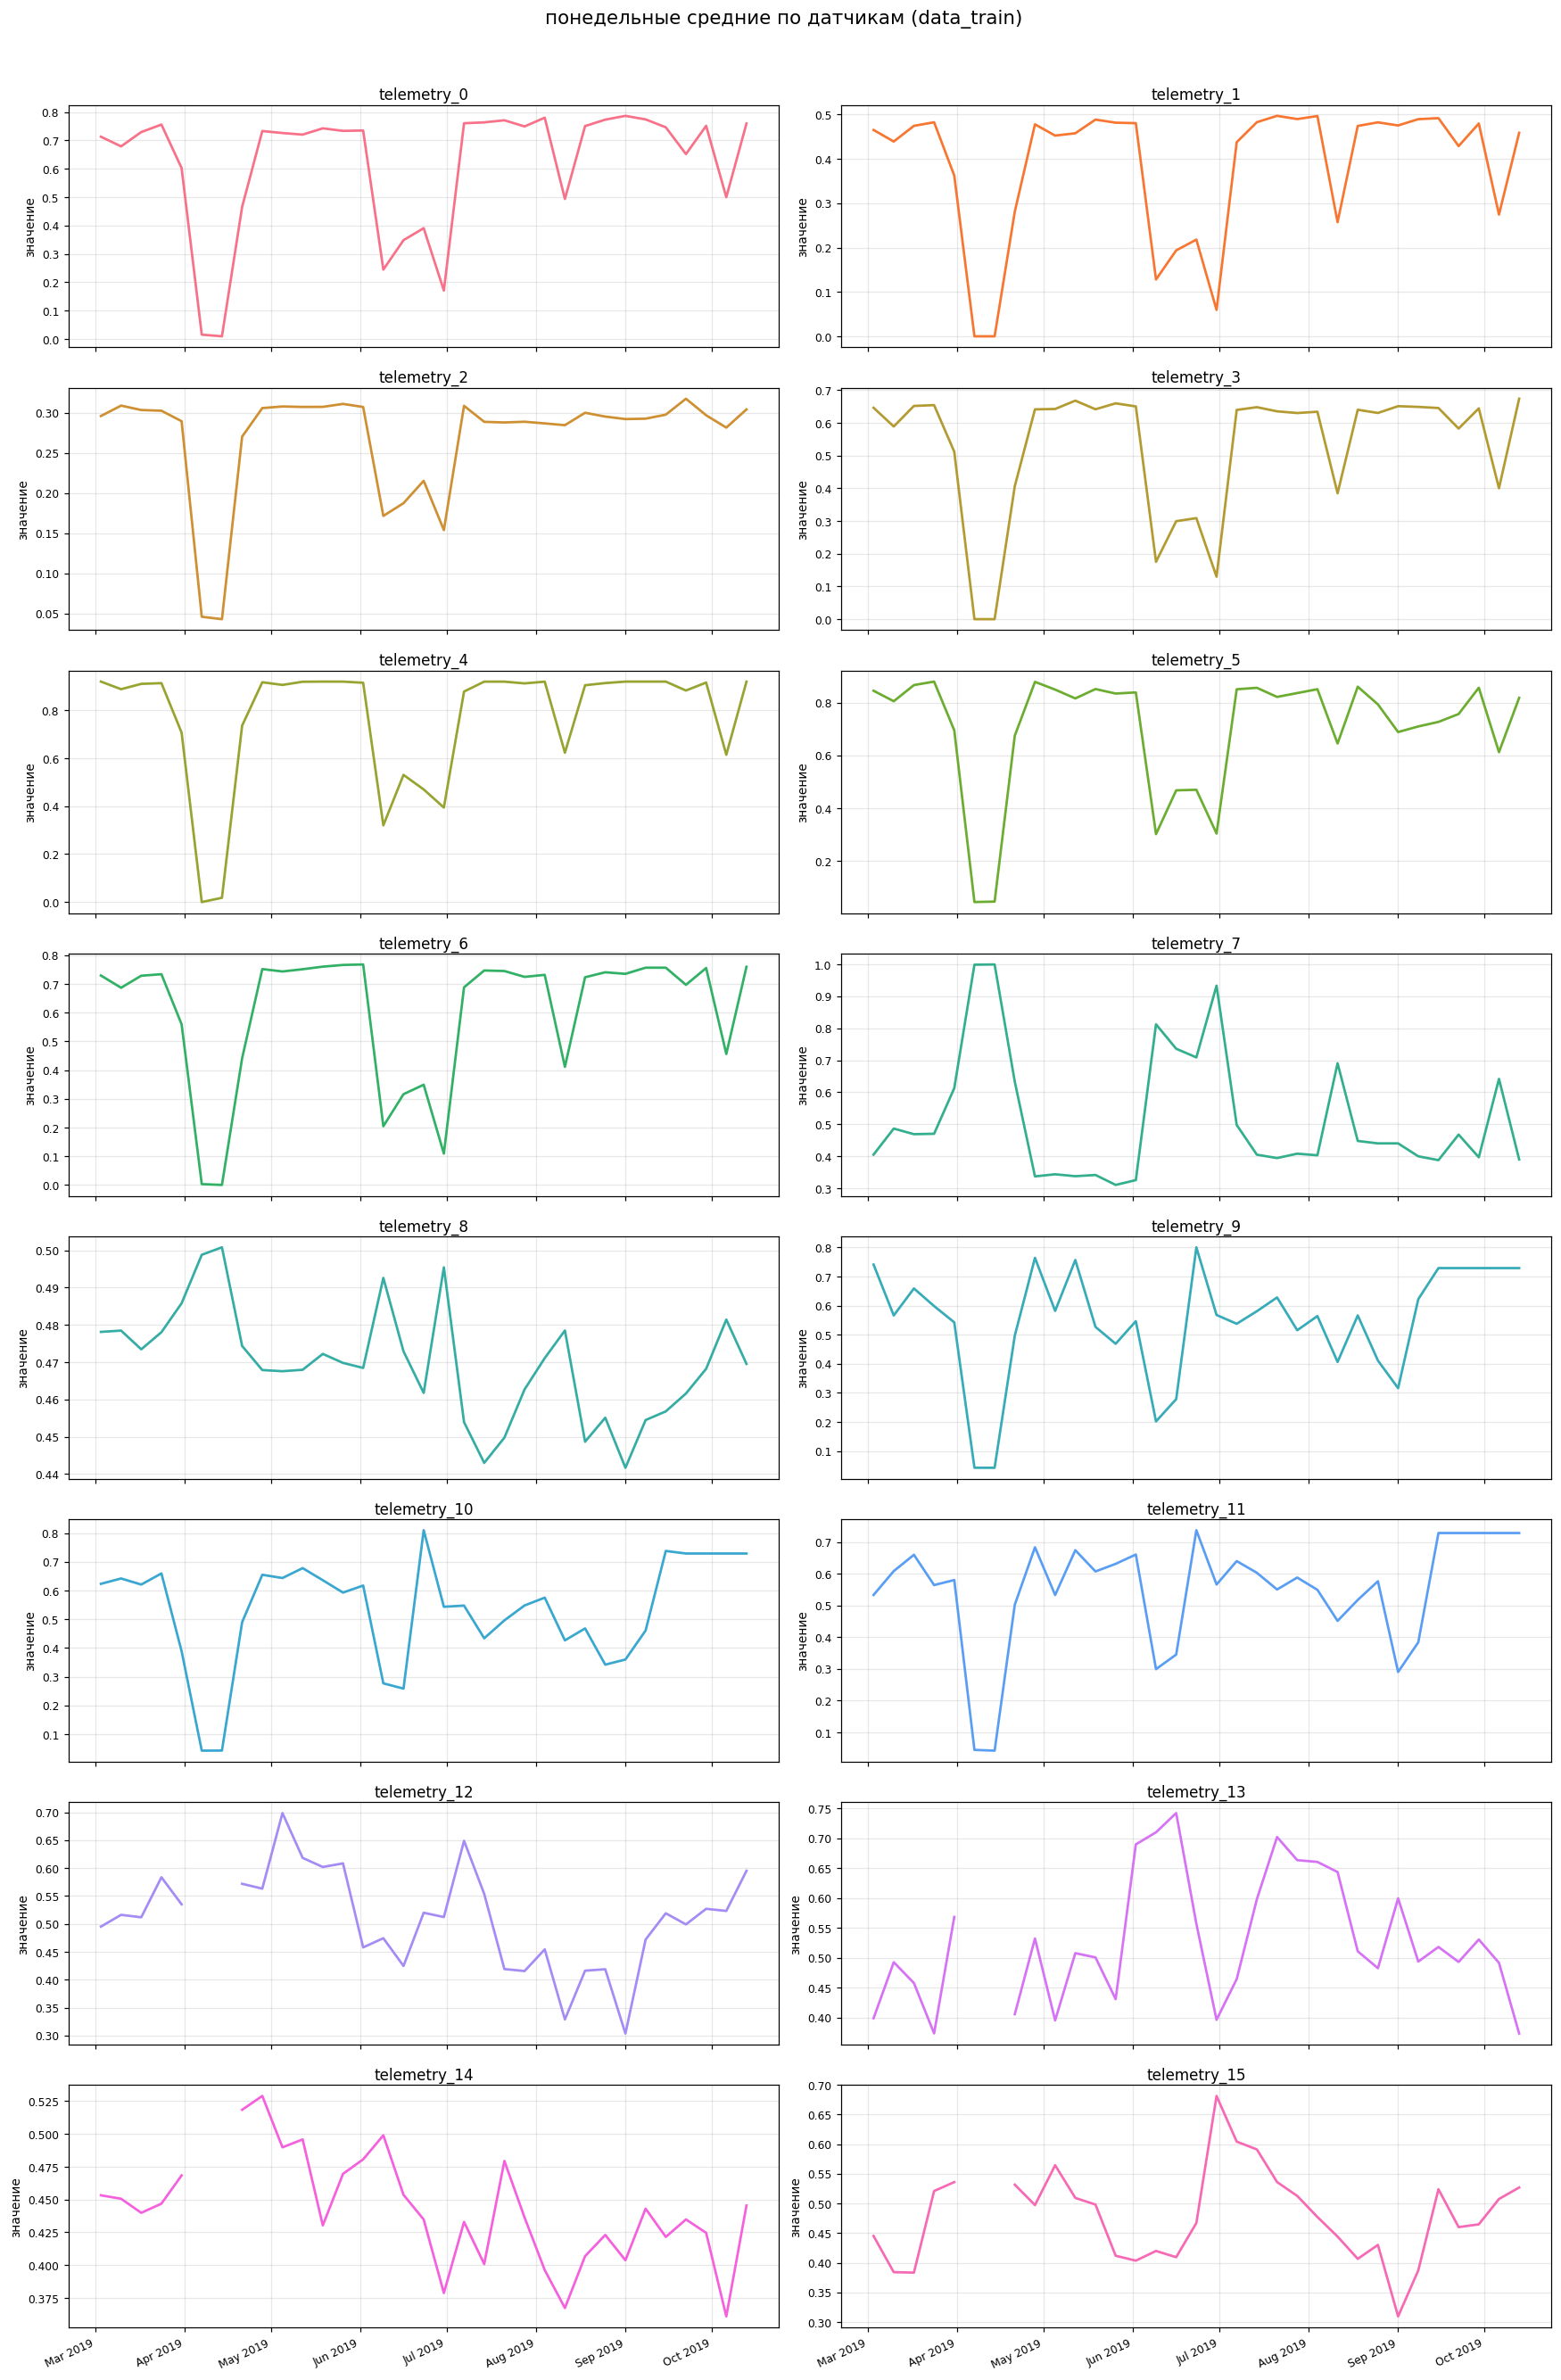

In [42]:
weekly = data_train.resample('W').mean()
cols   = list(data_train.columns)

fig, axes = plt.subplots(8, 2, figsize=(16, 24), sharex=True)
axes = axes.flatten()
palette = sns.color_palette('husl', 16)

x_plot = _safe_datetime_index_like(weekly.index)

for i, col in enumerate(cols):
    x = x_plot if x_plot is not None else np.arange(len(weekly))
    axes[i].plot(x, weekly[col].values, lw=1.8, color=palette[i])
    axes[i].set_title(col, fontsize=11, pad=4)
    axes[i].set_ylabel('значение', fontsize=9)
    axes[i].tick_params(labelsize=8)
    if x_plot is not None:
        axes[i].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

fig.suptitle('понедельные средние по датчикам (data_train)', fontsize=14, y=1.01)
if x_plot is not None:
    fig.autofmt_xdate(rotation=25)
plt.tight_layout()
plt.show()

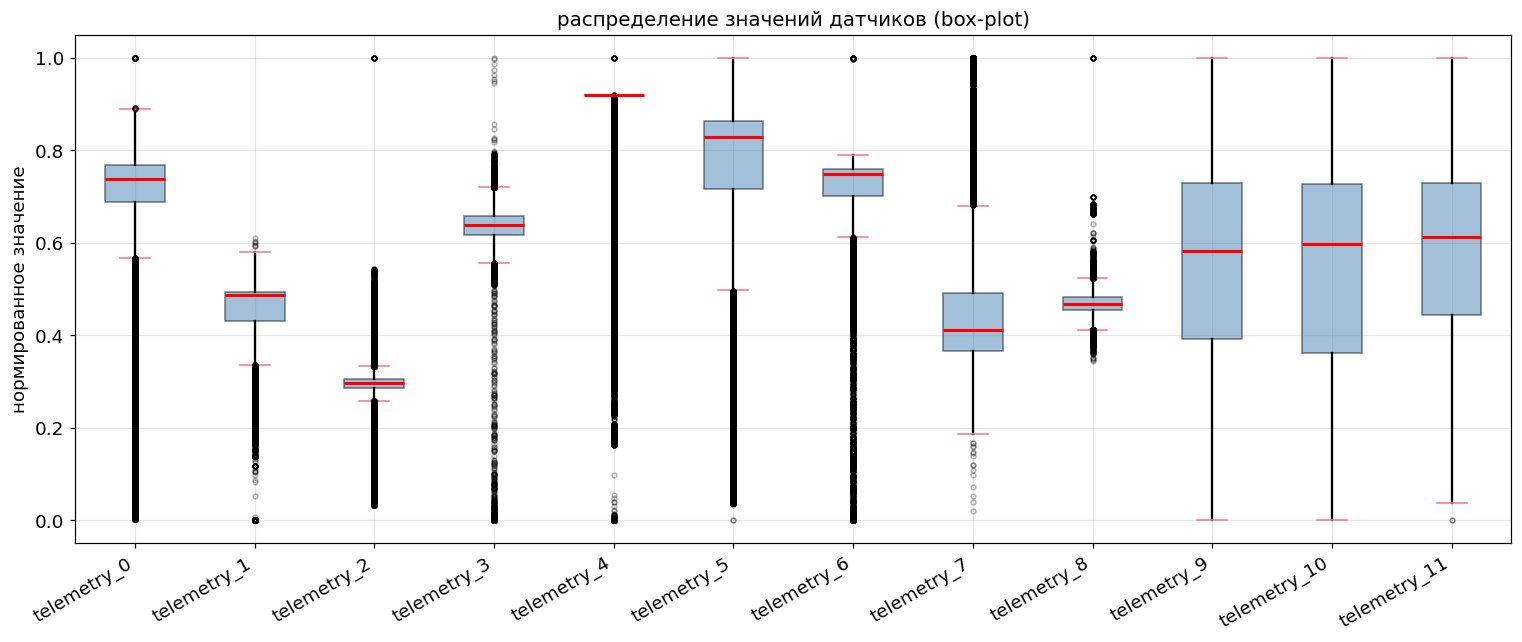

In [43]:
cols_full = [c for c in data_train.columns if data_train[c].isnull().mean() < 0.5]

fig, ax = plt.subplots(figsize=(14, 6))
data_train[cols_full].plot.box(
    ax=ax, patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.5),
    medianprops=dict(color='red', lw=2),
    whiskerprops=dict(lw=1.5),
    flierprops=dict(marker='o', ms=3, alpha=0.3)
)
ax.set_title('распределение значений датчиков (box-plot)', fontsize=13)
ax.set_ylabel('нормированное значение')
ax.set_xticklabels(cols_full, rotation=30, ha='right')
plt.tight_layout()
plt.show()

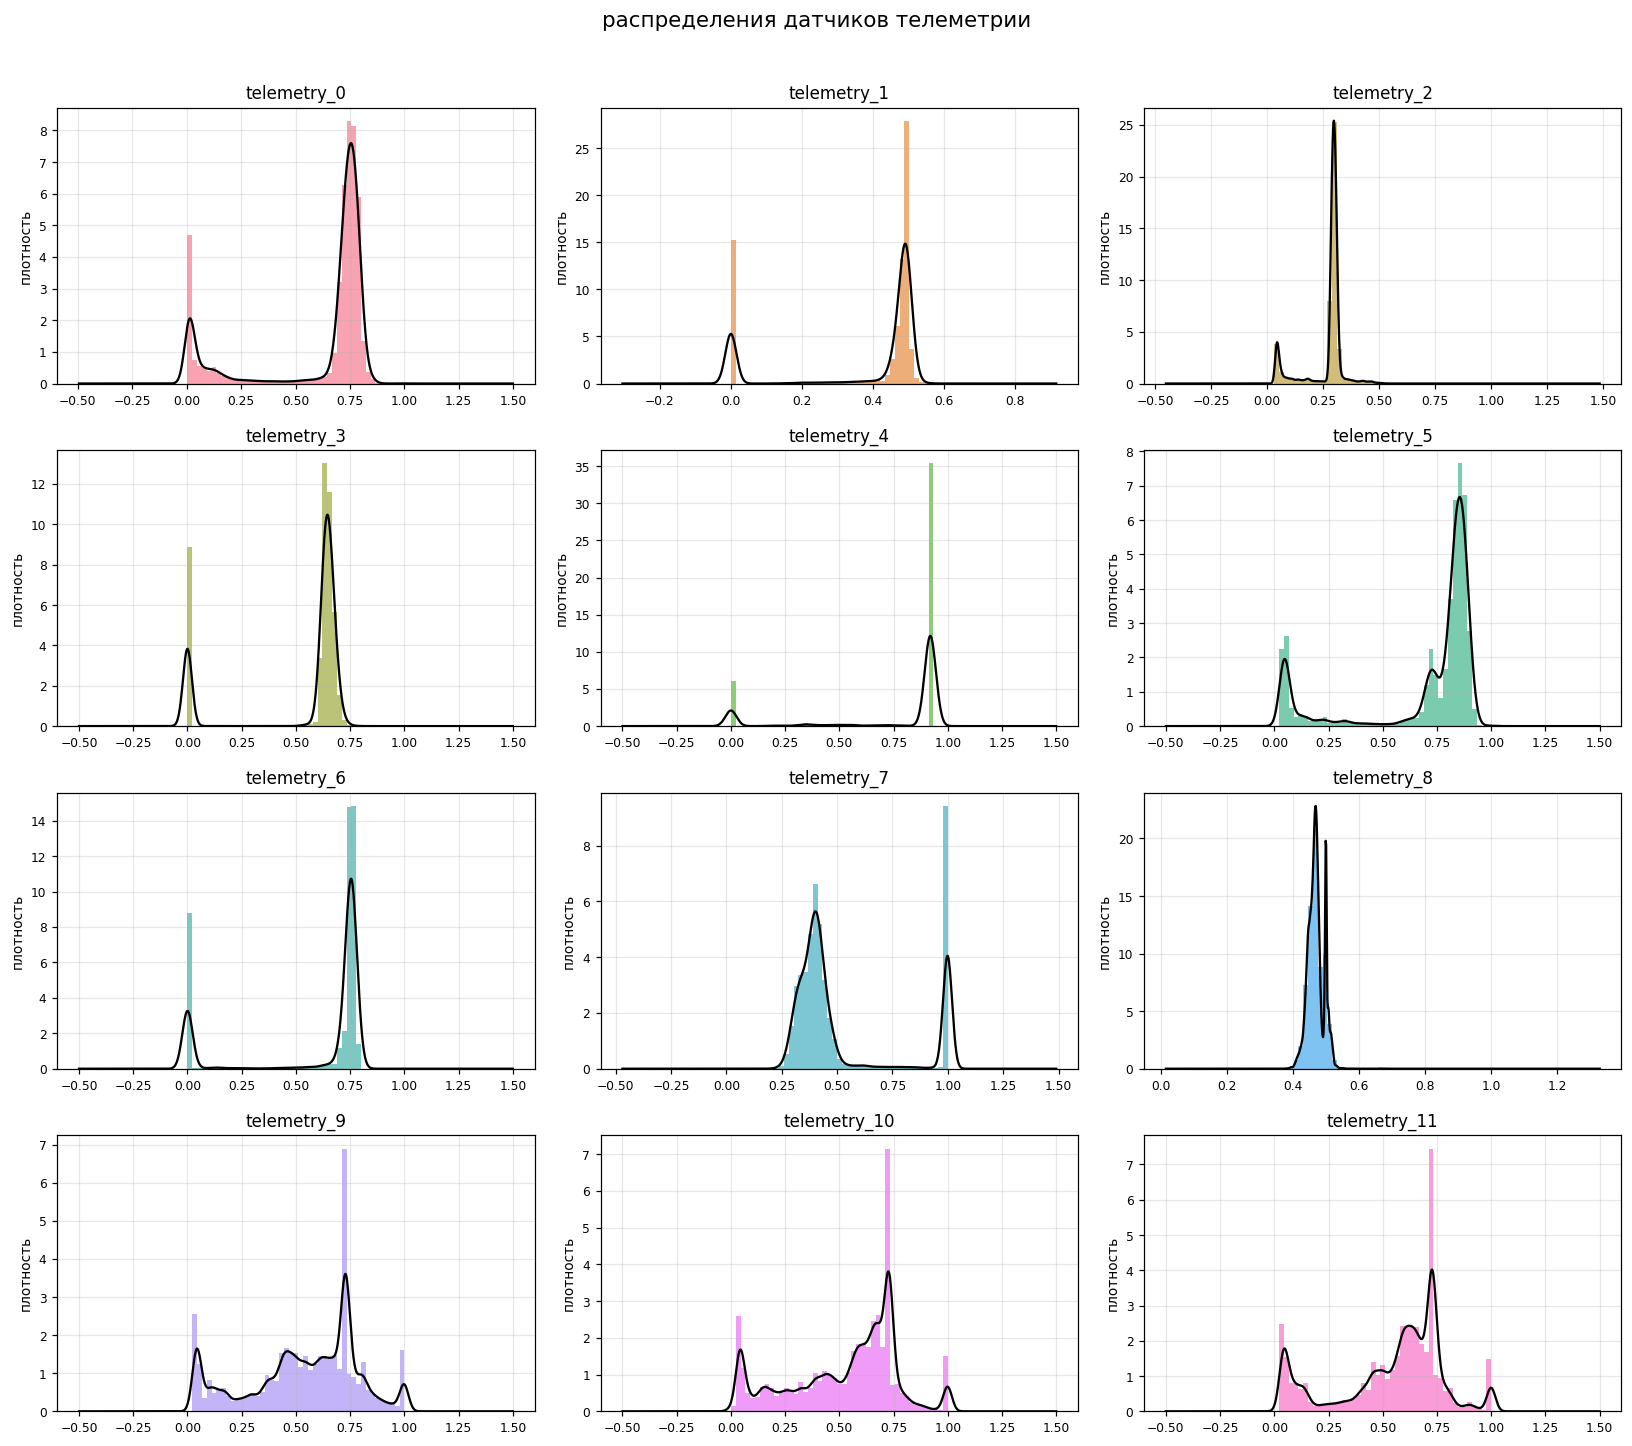

In [44]:
n = len(cols_full)
fig, axes = plt.subplots(4, 3, figsize=(15, 13))
axes = axes.flatten()
palette = sns.color_palette('husl', n)

for i, col in enumerate(cols_full):
    vals = data_train[col].dropna()
    axes[i].hist(vals, bins=45, density=True, color=palette[i], alpha=0.65, edgecolor='none')
    vals.plot.kde(ax=axes[i], color='black', lw=1.5)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('плотность', fontsize=9)
    axes[i].tick_params(labelsize=8)

fig.suptitle('распределения датчиков телеметрии', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.1.3 Целевая переменная

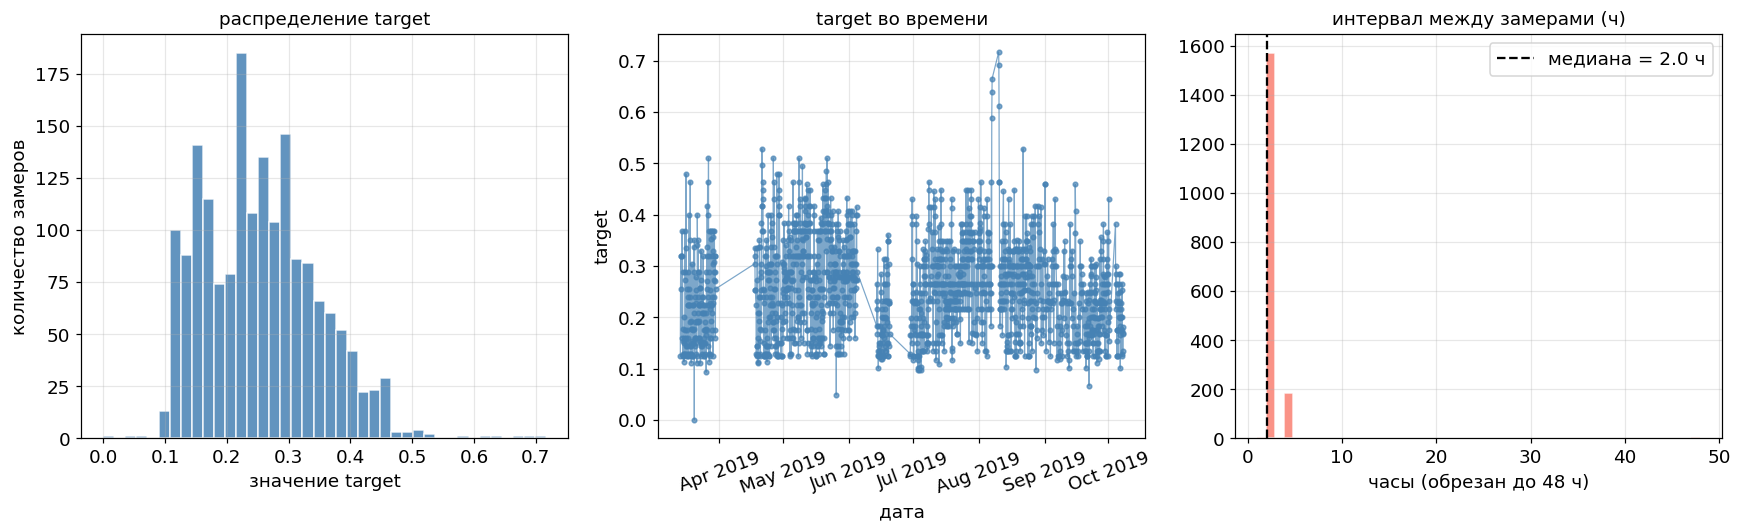

In [45]:
gaps = target_train.index.to_series().diff().dt.total_seconds().div(3600).dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(target_train['target'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('распределение target', fontsize=12)
axes[0].set_xlabel('значение target')
axes[0].set_ylabel('количество замеров')

x_plot = _safe_datetime_index_like(target_train.index)
if x_plot is not None:
    axes[1].plot(x_plot, target_train['target'].values, 'o-',
                 ms=3, lw=0.8, color='steelblue', alpha=0.7)
    axes[1].set_xlabel('дата')
    axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    axes[1].tick_params(axis='x', rotation=20)
else:
    axes[1].plot(np.arange(len(target_train)), target_train['target'].values, 'o-',
                 ms=3, lw=0.8, color='steelblue', alpha=0.7)
    axes[1].set_xlabel('номер наблюдения')

axes[1].set_title('target во времени', fontsize=12)
axes[1].set_ylabel('target')

axes[2].hist(gaps.clip(upper=48), bins=50, color='salmon', edgecolor='white', alpha=0.85)
axes[2].set_title('интервал между замерами (ч)', fontsize=12)
axes[2].set_xlabel('часы (обрезан до 48 ч)')
axes[2].axvline(gaps.median(), color='black', lw=1.5, linestyle='--',
                label=f'медиана = {gaps.median():.1f} ч')
axes[2].legend()

plt.tight_layout()
plt.show()

### 2.1.4 Синхронизация источников

выбрана задержка DELAY_MIN = 11 мин


,delay_minutes,samples,mean_abs_corr
0,10,1772,0.084579
1,11,1772,0.085236
2,12,1771,0.085012
3,13,1772,0.084655
4,14,1772,0.083853
5,15,1772,0.083813


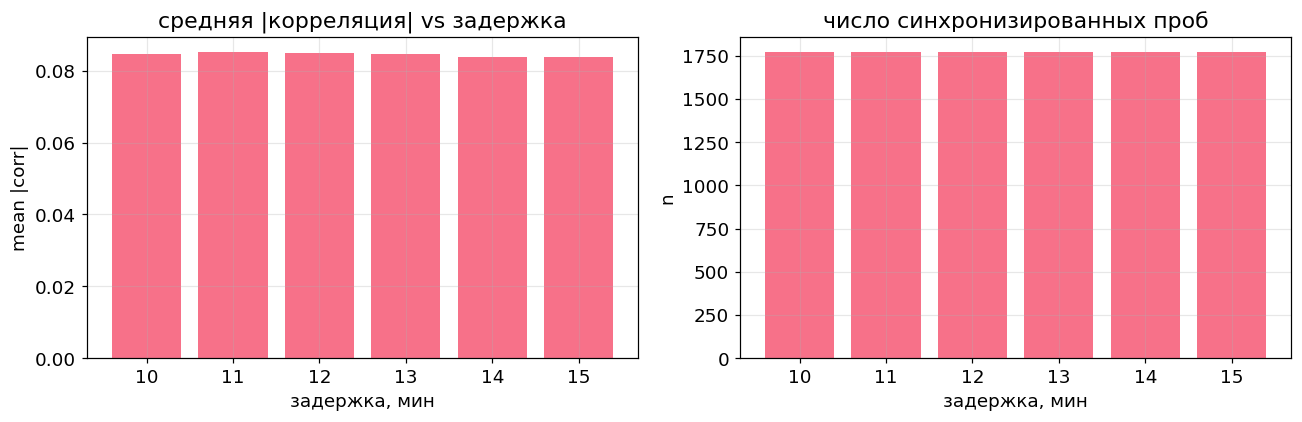

замеров после sync: 1772 (из 1773 исходных)


,telemetry_0,telemetry_1,target
datetime_y,,,
2019-03-13 16:49:00,0.787305,0.502351,0.123711
2019-03-13 20:49:00,0.781807,0.496872,0.319588
2019-03-14 00:49:00,0.786726,0.497651,0.255155
2019-03-14 04:49:00,0.749401,0.490628,0.319588
2019-03-14 08:49:00,0.767340,0.492402,0.159794


In [46]:
LAB_DELAY_CANDIDATES = list(range(10, 16))
SYNC_TOLERANCE = '10min'

def select_best_delay(telemetry_frame, target_frame, delay_candidates, tolerance='10min'):
    """выбирает задержку, при которой телеметрия лучше всего согласуется с target."""
    rows = []
    telem_cols = [c for c in telemetry_frame.columns if c.startswith('telemetry_')]

    for delay in delay_candidates:
        shifted = target_frame.copy().reset_index()
        if 'datetime' not in shifted.columns:
            shifted = shifted.rename(columns={'index': 'datetime'})
        telemetry_reset = telemetry_frame.copy().reset_index()
        if 'datetime' not in telemetry_reset.columns:
            telemetry_reset = telemetry_reset.rename(columns={'index': 'datetime'})

        shifted['sample_time'] = shifted['datetime'] - pd.Timedelta(minutes=delay)

        merged = pd.merge_asof(
            shifted.sort_values('sample_time'),
            telemetry_reset.sort_values('datetime'),
            left_on='sample_time',
            right_on='datetime',
            direction='backward',
            tolerance=pd.Timedelta(tolerance)
        )

        matched = merged.dropna(subset=['target']).copy()
        matched = matched.dropna(subset=[c for c in telem_cols if c in matched.columns], how='all')

        corrs = []
        for col in telem_cols:
            if col in matched.columns and matched[col].notna().sum() >= 5:
                corr = matched[col].corr(matched['target'])
                if pd.notna(corr):
                    corrs.append(abs(corr))

        rows.append({
            'delay_minutes': delay,
            'samples': len(matched),
            'mean_abs_corr': float(np.mean(corrs)) if corrs else np.nan
        })

    report = pd.DataFrame(rows).sort_values(['mean_abs_corr', 'samples'], ascending=[False, False])
    if report['mean_abs_corr'].notna().any():
        best_delay = int(report.iloc[0]['delay_minutes'])
    else:
        best_delay = 12
    return best_delay, report

DELAY_MIN, delay_report = select_best_delay(
    data_train,
    target_train,
    LAB_DELAY_CANDIDATES,
    tolerance=SYNC_TOLERANCE
)

print(f'выбрана задержка DELAY_MIN = {DELAY_MIN} мин')
display(delay_report.sort_values('delay_minutes'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rep = delay_report.sort_values('delay_minutes')
axes[0].bar(rep['delay_minutes'].astype(str), rep['mean_abs_corr'])
axes[0].set_title('средняя |корреляция| vs задержка')
axes[0].set_xlabel('задержка, мин')
axes[0].set_ylabel('mean |corr|')

axes[1].bar(rep['delay_minutes'].astype(str), rep['samples'])
axes[1].set_title('число синхронизированных проб')
axes[1].set_xlabel('задержка, мин')
axes[1].set_ylabel('n')
plt.tight_layout()
plt.show()

# сдвигаем лабораторный замер к предполагаемому времени отбора пробы
# и присоединяем к каждой пробе одно ближайшее прошлое состояние процесса.
target_adj = target_train.copy()
target_adj['sample_time'] = target_adj.index - pd.Timedelta(minutes=DELAY_MIN)

labeled = pd.merge_asof(
    target_adj.sort_values('sample_time').reset_index(),
    data_train.sort_index().reset_index(),
    left_on='sample_time',
    right_on='datetime',
    direction='backward',
    tolerance=pd.Timedelta(SYNC_TOLERANCE)
)

# после merge_asof получаются datetime_x (время лабораторного замера) и
# datetime_y (время найденной строки телеметрии). В индекс ставим именно datetime_y.
time_col = 'datetime_y' if 'datetime_y' in labeled.columns else ('feature_time' if 'feature_time' in labeled.columns else 'datetime')
labeled = labeled.dropna(subset=['target', time_col]).set_index(time_col).sort_index()

print(f'замеров после sync: {len(labeled)} (из {len(target_adj)} исходных)')
display_cols = [c for c in ['telemetry_0', 'telemetry_1', 'target'] if c in labeled.columns]
labeled[display_cols].head()


### 2.1.5 Корреляционный анализ

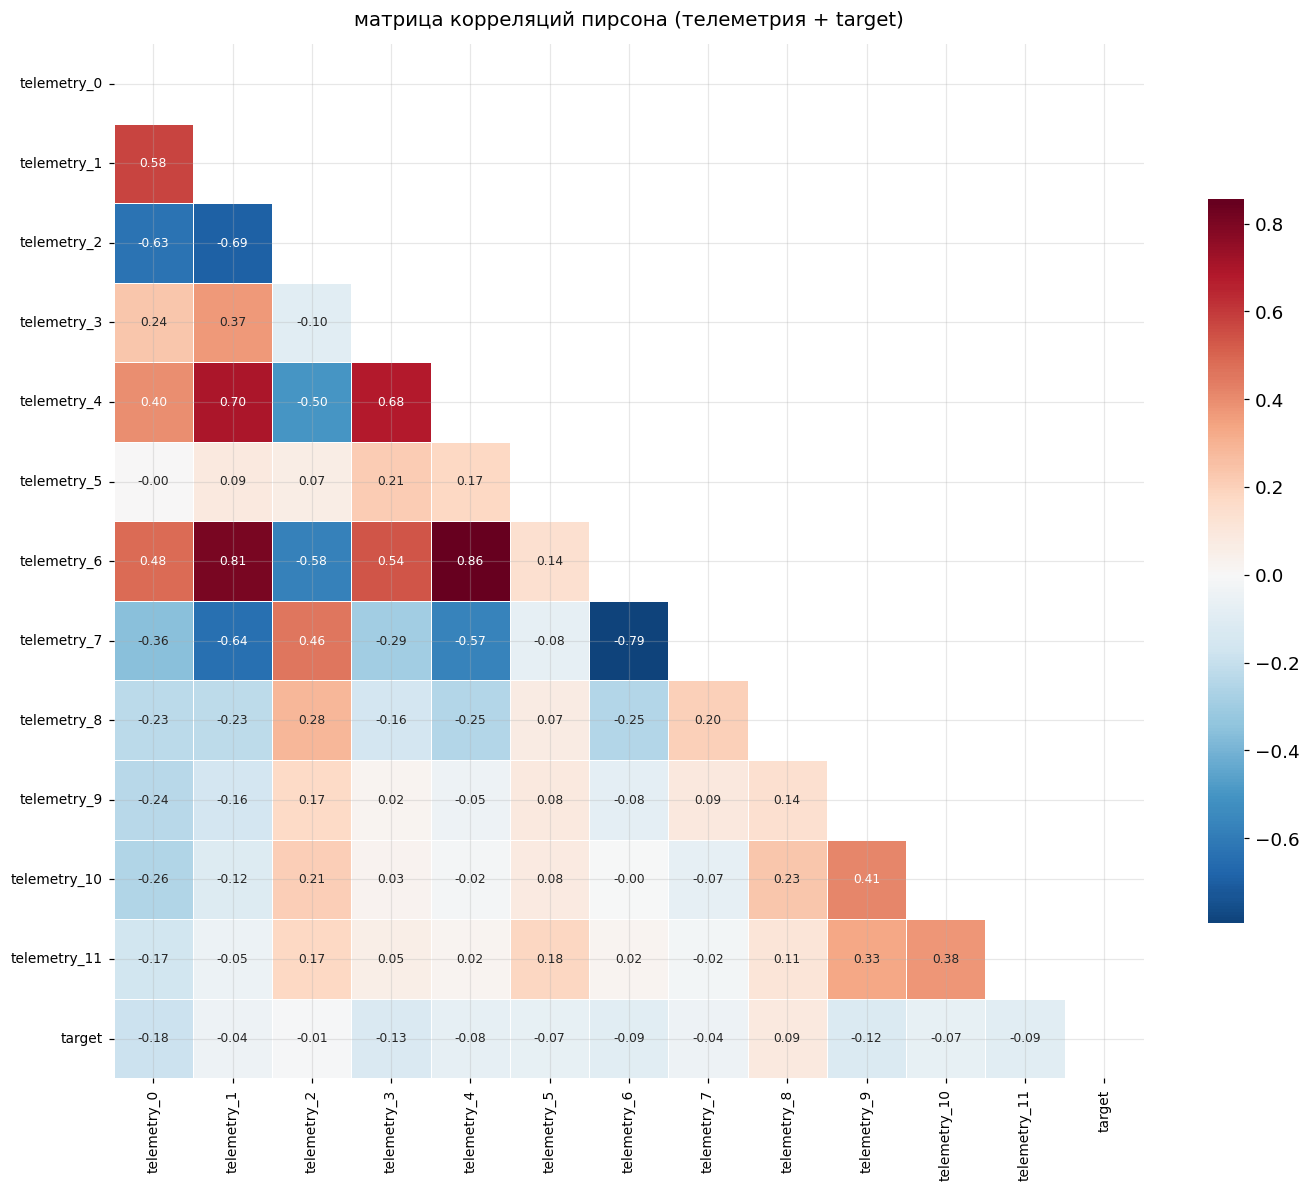

In [47]:
corr = labeled[cols_full + ['target']].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.4,
    annot_kws={'size': 8}, ax=ax,
    cbar_kws={'shrink': 0.7}
)
ax.set_title('матрица корреляций пирсона (телеметрия + target)', fontsize=13, pad=12)
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

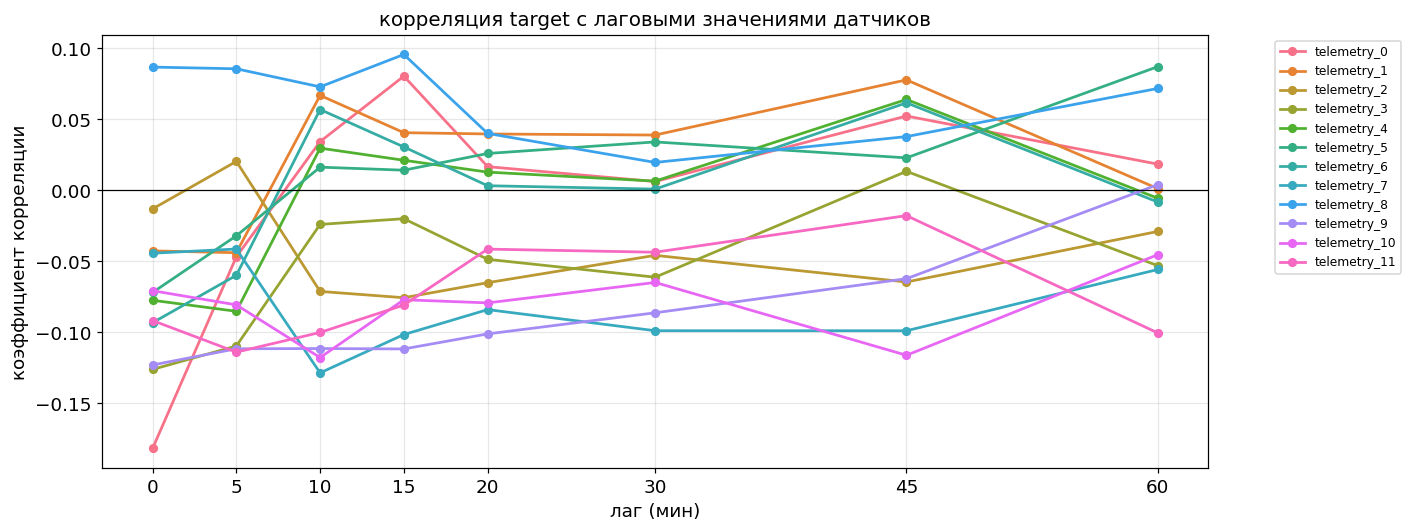

топ-5 датчиков по макс |корреляции| с target:
telemetry_0     0.182
telemetry_7     0.129
telemetry_3     0.126
telemetry_9     0.123
telemetry_10    0.118


In [48]:
lag_steps = [0, 5, 10, 15, 20, 30, 45, 60]
lag_corrs  = {lag: labeled[cols_full].shift(lag).corrwith(labeled['target'])
              for lag in lag_steps}
lag_corr_df = pd.DataFrame(lag_corrs, index=cols_full).T

fig, ax = plt.subplots(figsize=(13, 5))
palette = sns.color_palette('husl', len(cols_full))
for i, col in enumerate(cols_full):
    ax.plot(lag_steps, lag_corr_df[col], marker='o', ms=5,
            lw=1.8, label=col, color=palette[i])
ax.axhline(0, color='black', lw=0.8)
ax.set_title('корреляция target с лаговыми значениями датчиков', fontsize=13)
ax.set_xlabel('лаг (мин)')
ax.set_ylabel('коэффициент корреляции')
ax.legend(loc='upper right', bbox_to_anchor=(1.18, 1.0), fontsize=8, framealpha=0.8)
ax.set_xticks(lag_steps)
plt.tight_layout()
plt.show()

print('топ-5 датчиков по макс |корреляции| с target:')
print(lag_corr_df.abs().max().sort_values(ascending=False).head(5).round(3).to_string())

### Вывод по EDA

1. **Пропуски**: датчики `telemetry_12`–`telemetry_15` отсутствуют в первые ~6 месяцев (~98–100% пропусков). Датчики 0–11 практически полны. Стратегия: для поздних датчиков — медианная импутация + бинарный флаг наличия, для остальных — линейная интерполяция с последующим forward-fill.
2. **Целевая переменная**: диапазон [0, 1], медианный интервал между замерами — несколько часов. Замеры нерегулярны — обычная ситуация для промышленного лабораторного контроля.
3. **Синхронизация**: компенсация лабораторной задержки 12 мин + допуск 2 часа при `merge_asof` корректно привязывает большинство замеров к телеметрии без утечки данных.
4. **Корреляции**: ряд датчиков показывает максимум корреляции с target при лаге 15–30 мин — подтверждает необходимость лаговых признаков.


---
## 2.2 Инжиниринг признаков

In [49]:

def preprocess_telemetry(df):
    df = df.copy()
    for col in df.columns:
        if df[col].isnull().mean() > 0.5:
            df[f'{col}_present'] = df[col].notna().astype(float)
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].interpolate(method='time', limit=30).ffill().bfill()
        q1, q3 = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(q1, q3)
    return df

def build_features(df, sensor_cols):
    result  = pd.DataFrame(index=df.index)
    LAGS    = [5, 10, 15, 30, 60]
    WINDOWS = [5, 15, 30, 60]

    for col in sensor_cols:
        s = df[col]
        result[col] = s
        for lag in LAGS:
            result[f'{col}_lag{lag}'] = s.shift(lag)
        for w in WINDOWS:
            roll = s.shift(1).rolling(w, min_periods=max(1, w // 2))
            result[f'{col}_rmean{w}'] = roll.mean()
            result[f'{col}_rstd{w}']  = roll.std()
            result[f'{col}_rmin{w}']  = roll.min()
            result[f'{col}_rmax{w}']  = roll.max()
        result[f'{col}_diff1'] = s.diff(1)
        result[f'{col}_diff5'] = s.diff(5)
        result[f'{col}_pct5']  = s.pct_change(5).replace([np.inf, -np.inf], np.nan).clip(-5, 5)

    hour = df.index.hour + df.index.minute / 60.0
    result['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    result['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    result['dow_sin']  = np.sin(2 * np.pi * df.index.dayofweek / 7)
    result['dow_cos']  = np.cos(2 * np.pi * df.index.dayofweek / 7)
    return result

def align_target_to_feature_rows(feature_frame, target_frame, delay_min=12, tolerance='10min'):
    shifted_target = target_frame.copy().reset_index().rename(columns={'datetime': 'target_time'})
    feature_reset  = feature_frame.copy().reset_index().rename(columns={'datetime': 'feature_time'})

    if 'index' in shifted_target.columns and 'target_time' not in shifted_target.columns:
        shifted_target = shifted_target.rename(columns={'index': 'target_time'})
    if 'index' in feature_reset.columns and 'feature_time' not in feature_reset.columns:
        feature_reset = feature_reset.rename(columns={'index': 'feature_time'})

    shifted_target['sample_time'] = shifted_target['target_time'] - pd.Timedelta(minutes=delay_min)

    aligned = pd.merge_asof(
        shifted_target.sort_values('sample_time'),
        feature_reset.sort_values('feature_time'),
        left_on='sample_time',
        right_on='feature_time',
        direction='backward',
        tolerance=pd.Timedelta(tolerance)
    )
    return aligned

train_clean = preprocess_telemetry(data_train)
test_clean  = preprocess_telemetry(data_test)
sensor_cols = [c for c in train_clean.columns if c.startswith('telemetry')]
print(f'датчиков после предобработки (с флагами): {len(sensor_cols)}')

датчиков после предобработки (с флагами): 20


In [50]:
X_train_full = build_features(train_clean, sensor_cols)
X_test_full  = build_features(test_clean,  sensor_cols)

for col in X_train_full.columns:
    if col not in X_test_full.columns:
        X_test_full[col] = 0.0
X_test_full = X_test_full[X_train_full.columns]

print(f'матрица признаков train: {X_train_full.shape}')
print(f'матрица признаков test:  {X_test_full.shape}')

матрица признаков train: (317998, 504)
матрица признаков test:  (39747, 504)


In [51]:

Xy_train = align_target_to_feature_rows(
    X_train_full,
    target_train,
    delay_min=DELAY_MIN,
    tolerance=SYNC_TOLERANCE
)

# оставляем только строки, где target сопоставлен с найденным в прошлом вектором признаков
Xy_train = Xy_train.dropna(subset=['target', 'feature_time']).set_index('feature_time').sort_index()

# убираем служебные временные колонки; в модель передаем только числовые признаки
cols_to_drop = ['target', 'sample_time', 'target_time']
X_train = Xy_train.drop(columns=[c for c in cols_to_drop if c in Xy_train.columns], errors='ignore')
X_train = X_train.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)

y_train = Xy_train['target'].copy()

# выравниваем тест по train-колонкам и заполняем пропуски статистиками train
X_test = X_test_full.reindex(columns=X_train.columns)
X_test = X_test.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)

feature_medians = X_train.median()
X_train = X_train.fillna(feature_medians).ffill().bfill().fillna(0.0)
X_test  = X_test.fillna(feature_medians).ffill().bfill().fillna(0.0)

print(f'обучение: X={X_train.shape}, y={y_train.shape}')
print(f'тест:     X={X_test.shape}')
print(f'одна строка train на один лабораторный замер: {len(X_train) == len(y_train)}')
print(f'NaN в X_train: {int(X_train.isna().sum().sum())}')
print(f'NaN в X_test:  {int(X_test.isna().sum().sum())}')


обучение: X=(1772, 504), y=(1772,)
тест:     X=(39747, 504)
одна строка train на один лабораторный замер: True
NaN в X_train: 0
NaN в X_test:  0


### Вывод по инжинирингу признаков

Итоговая матрица теперь формируется корректно: сначала строятся признаки по минутной телеметрии, затем **каждому лабораторному замеру сопоставляется один ближайший прошлый вектор признаков** с учётом технологической задержки `DELAY_MIN`. Это устраняет размножение target на множество минутных наблюдений и делает обучающую выборку методически корректной.


---
## 2.3 Построение прогнозных моделей

### Обоснование выбора моделей

#### ✅ Выбранные модели

| Модель | Обоснование |
|---|---|
| **Ridge Regression** | быстрый интерпретируемый baseline; устойчив к мультиколлинеарности лаговых признаков |
| **Random Forest** | нелинейная модель, не требует масштабирования, устойчива к выбросам, встроенная оценка важности признаков |
| **Gradient Boosting** | ансамблевое бустирование деревьев — обычно лучший баланс точности и интерпретируемости на табличных данных с временными признаками |

#### ❌ Модели, которые **не подойдут**

| Модель | Причина |
|---|---|
| **ARIMA / SARIMA** | одномерные модели для равномерных рядов; целевой ряд нерегулярен, к тому же задача — предсказать таргет по телеметрии, а не продолжить сам ряд |
| **LSTM / RNN** | требуют больших объёмов меченых данных (~1700 замеров — мало); риск переобучения; минимальная интерпретируемость |
| **k-NN Regressor** | при 500+ признаках «проклятие размерности» делает метрику расстояния бессмысленной; медленный инференс |


In [52]:
split_idx = int(len(X_train) * 0.80)
X_tr,  y_tr  = X_train.iloc[:split_idx], y_train.iloc[:split_idx]
X_val, y_val = X_train.iloc[split_idx:], y_train.iloc[split_idx:]

print(f'train: {len(X_tr):,}  ({X_tr.index.min().date()} — {X_tr.index.max().date()})')
print(f'val:   {len(X_val):,}  ({X_val.index.min().date()} — {X_val.index.max().date()})')

train: 1,417  (2019-03-13 — 2019-08-23)
val:   355  (2019-08-24 — 2019-10-07)


In [53]:
def mape(y_true, y_pred, eps=1e-6):
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps))) * 100

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def da(y_true, y_pred):
    return np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100

def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'MAE':  round(mean_absolute_error(y_true, y_pred), 5),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 5),
        'MAPE': round(mape(y_true, y_pred), 2),
        'WAPE': round(wape(y_true, y_pred), 2),
        'DA%':  round(da(np.array(y_true), np.array(y_pred)), 1),
    }

results = []

In [54]:

pipe_ridge = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])
pipe_ridge.fit(X_tr, y_tr)
pred_ridge_val = pipe_ridge.predict(X_val)

res = evaluate('Ridge', y_val, pred_ridge_val)
results.append(res)
print(res)

{'Model': 'Ridge', 'MAE': 0.08377, 'RMSE': 0.11221, 'MAPE': 47.55, 'WAPE': 37.09, 'DA%': 47.7}


In [55]:

pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        n_jobs=-1, random_state=SEED
    ))
])
pipe_rf.fit(X_tr, y_tr)
pred_rf_val = pipe_rf.predict(X_val)
rf = pipe_rf.named_steps['model']

res = evaluate('RandomForest', y_val, pred_rf_val)
results.append(res)
print(res)

{'Model': 'RandomForest', 'MAE': 0.0694, 'RMSE': 0.08534, 'MAPE': 39.06, 'WAPE': 30.72, 'DA%': 52.0}


In [56]:

pipe_gb = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        min_samples_leaf=5, subsample=0.8, random_state=SEED
    ))
])
pipe_gb.fit(X_tr, y_tr)
pred_gb_val = pipe_gb.predict(X_val)
gb = pipe_gb.named_steps['model']

res = evaluate('GradientBoosting', y_val, pred_gb_val)
results.append(res)
print(res)

{'Model': 'GradientBoosting', 'MAE': 0.07217, 'RMSE': 0.08968, 'MAPE': 39.83, 'WAPE': 31.95, 'DA%': 48.0}


In [57]:
results_df = pd.DataFrame(results).set_index('Model')
results_df

,MAE,RMSE,MAPE,WAPE,DA%
Model,,,,,
Ridge,0.08377,0.11221,47.55,37.09,47.7
RandomForest,0.06940,0.08534,39.06,30.72,52.0
GradientBoosting,0.07217,0.08968,39.83,31.95,48.0


In [58]:
# дополнительная проверка устойчивости лучшей прикладной модели на временных фолдах
tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []

for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_train), start=1):
    X_fold_tr, X_fold_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_fold_tr, y_fold_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    fold_model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            min_samples_leaf=5, subsample=0.8, random_state=SEED
        ))
    ])
    fold_model.fit(X_fold_tr, y_fold_tr)
    fold_pred = fold_model.predict(X_fold_te)

    cv_rows.append({
        'fold': fold,
        'MAE': mean_absolute_error(y_fold_te, fold_pred),
        'RMSE': np.sqrt(mean_squared_error(y_fold_te, fold_pred))
    })

cv_report = pd.DataFrame(cv_rows)
display(cv_report.round(5))
print('TimeSeriesSplit mean MAE =', round(cv_report['MAE'].mean(), 5))
print('TimeSeriesSplit mean RMSE =', round(cv_report['RMSE'].mean(), 5))

,fold,MAE,RMSE
0,1,0.07754,0.09416
1,2,0.07212,0.08770
2,3,0.06861,0.08710
3,4,0.07642,0.10739
4,5,0.06830,0.08454


TimeSeriesSplit mean MAE = 0.0726
TimeSeriesSplit mean RMSE = 0.09218


---
## 2.3 (продолжение) Оценка качества моделей

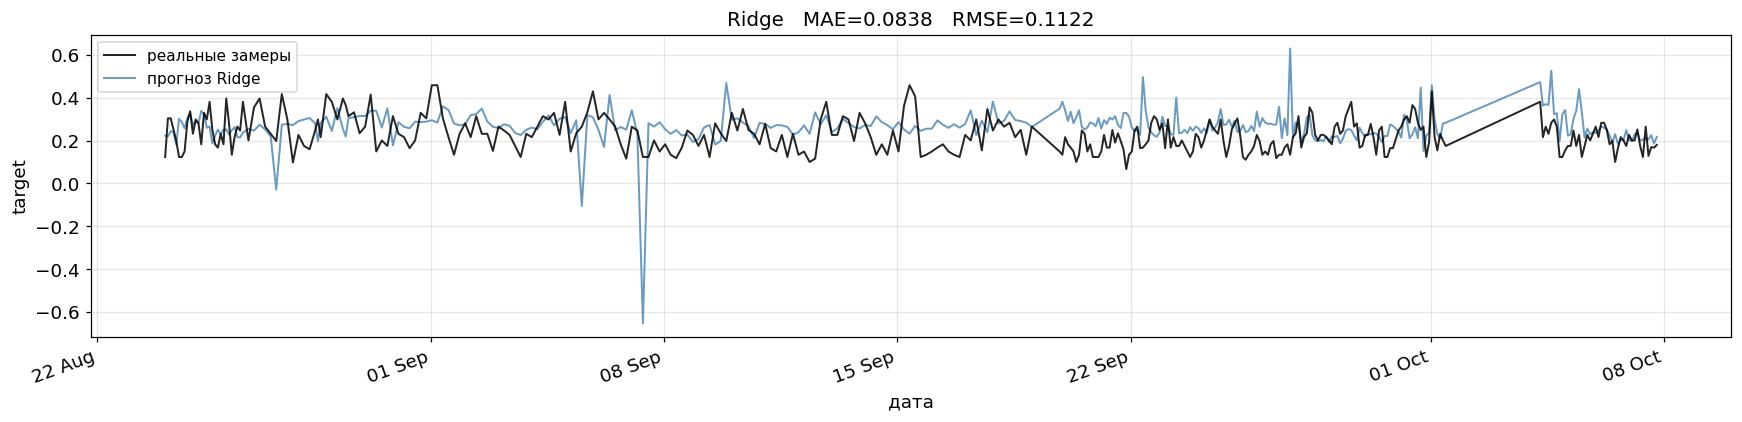

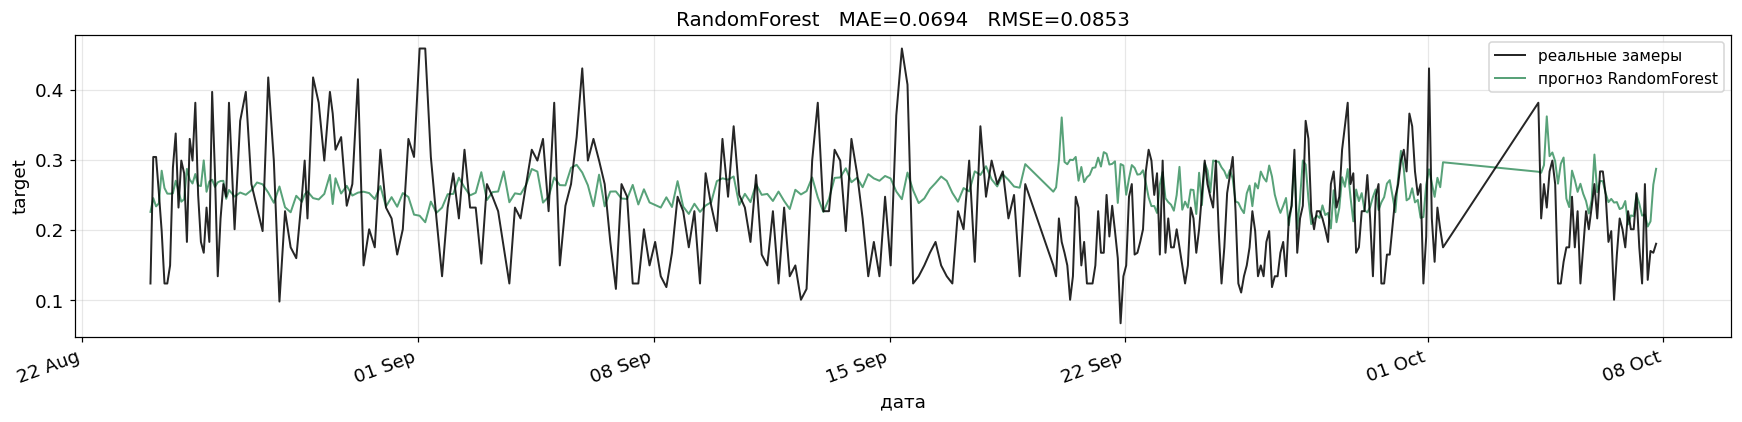

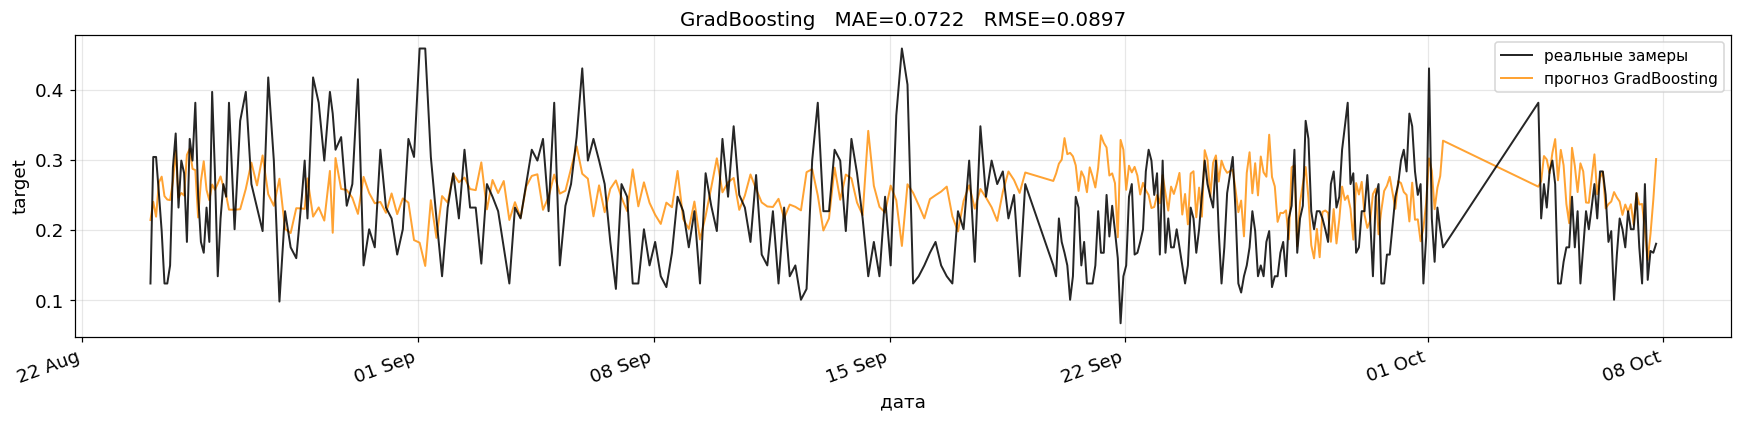

In [59]:
models_info = [
    ('Ridge',          pred_ridge_val, 'steelblue'),
    ('RandomForest',   pred_rf_val,    'seagreen'),
    ('GradBoosting',   pred_gb_val,    'darkorange'),
]

x_plot = _safe_datetime_index_like(y_val.index)

for name, pred, color in models_info:
    mae_v  = mean_absolute_error(y_val, pred)
    rmse_v = np.sqrt(mean_squared_error(y_val, pred))

    fig, ax = plt.subplots(figsize=(16, 4))
    if x_plot is not None:
        ax.plot(x_plot, y_val.values, color='black', lw=1.3,
                label='реальные замеры', alpha=0.85, zorder=3)
        ax.plot(x_plot, np.asarray(pred), color=color, lw=1.3,
                label=f'прогноз {name}', alpha=0.8, zorder=2)
        ax.set_xlabel('дата')
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
    else:
        ax.plot(np.arange(len(y_val)), y_val.values, color='black', lw=1.3,
                label='реальные замеры', alpha=0.85, zorder=3)
        ax.plot(np.arange(len(pred)), np.asarray(pred), color=color, lw=1.3,
                label=f'прогноз {name}', alpha=0.8, zorder=2)
        ax.set_xlabel('номер наблюдения')

    ax.set_title(f'{name}   MAE={mae_v:.4f}   RMSE={rmse_v:.4f}', fontsize=13)
    ax.set_ylabel('target')
    ax.legend(fontsize=10)
    fig.autofmt_xdate(rotation=20)
    plt.tight_layout()
    plt.show()

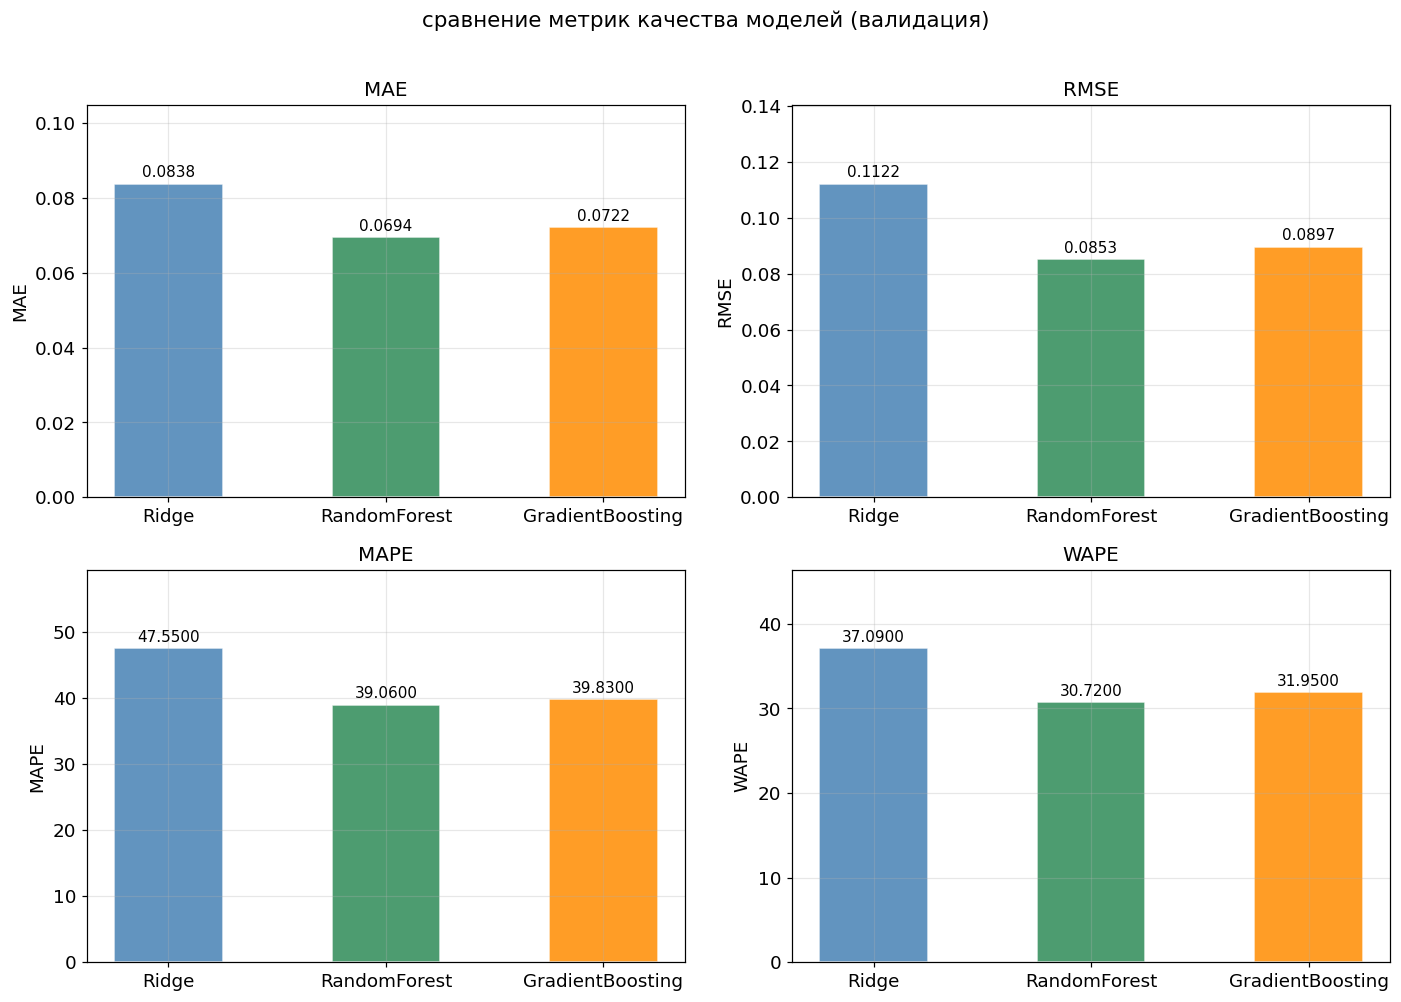

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes  = axes.flatten()
colors = ['steelblue', 'seagreen', 'darkorange']

for i, metric in enumerate(['MAE', 'RMSE', 'MAPE', 'WAPE']):
    bars = axes[i].bar(results_df.index, results_df[metric],
                       color=colors, edgecolor='white', alpha=0.85, width=0.5)
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_ylabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + results_df[metric].max() * 0.01,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    axes[i].set_ylim(0, results_df[metric].max() * 1.25)

fig.suptitle('сравнение метрик качества моделей (валидация)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

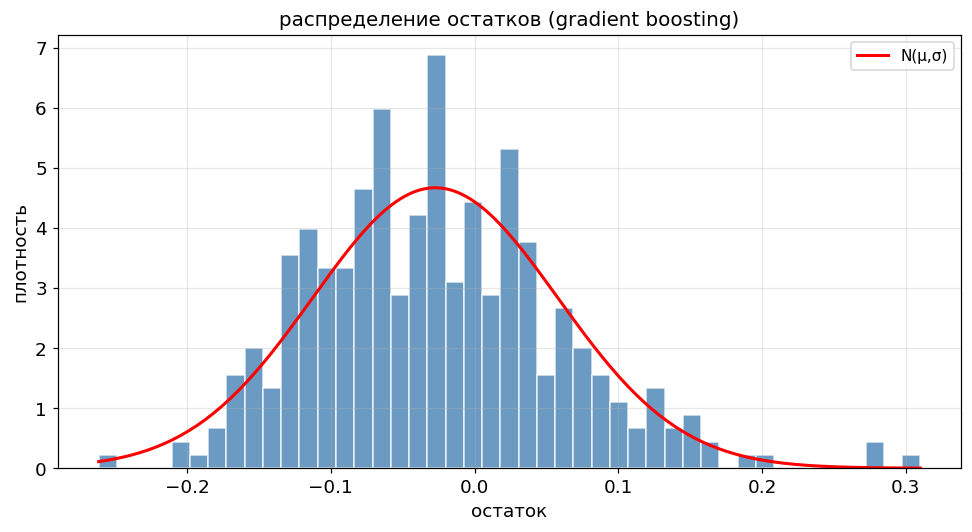

In [61]:
residuals = y_val.values - pred_gb_val

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuals, bins=45, density=True, color='steelblue', edgecolor='white', alpha=0.8)
x_norm = np.linspace(residuals.min(), residuals.max(), 200)
ax.plot(x_norm, stats.norm.pdf(x_norm, residuals.mean(), residuals.std()),
        'r-', lw=2, label='N(μ,σ)')
ax.set_title('распределение остатков (gradient boosting)', fontsize=13)
ax.set_xlabel('остаток')
ax.set_ylabel('плотность')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

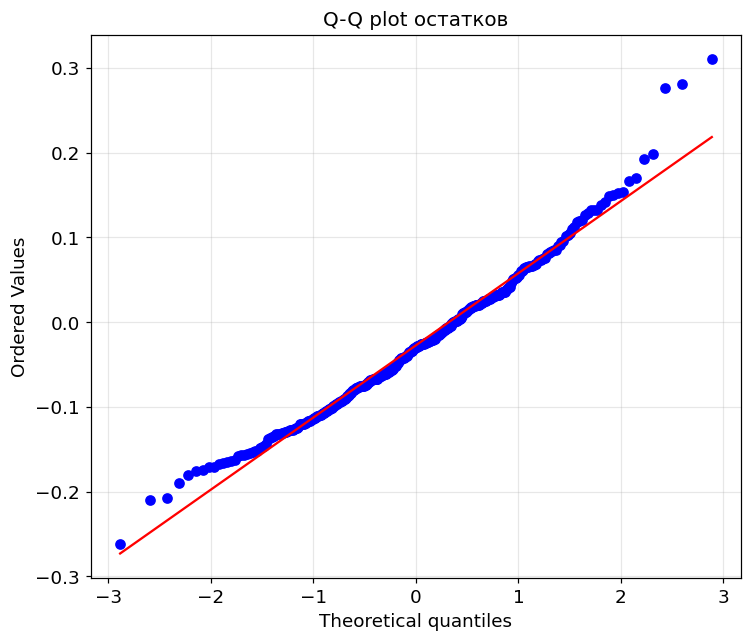

In [62]:
fig, ax = plt.subplots(figsize=(7, 6))
stats.probplot(residuals, dist='norm', plot=ax)
ax.set_title('Q-Q plot остатков', fontsize=13)
plt.tight_layout()
plt.show()

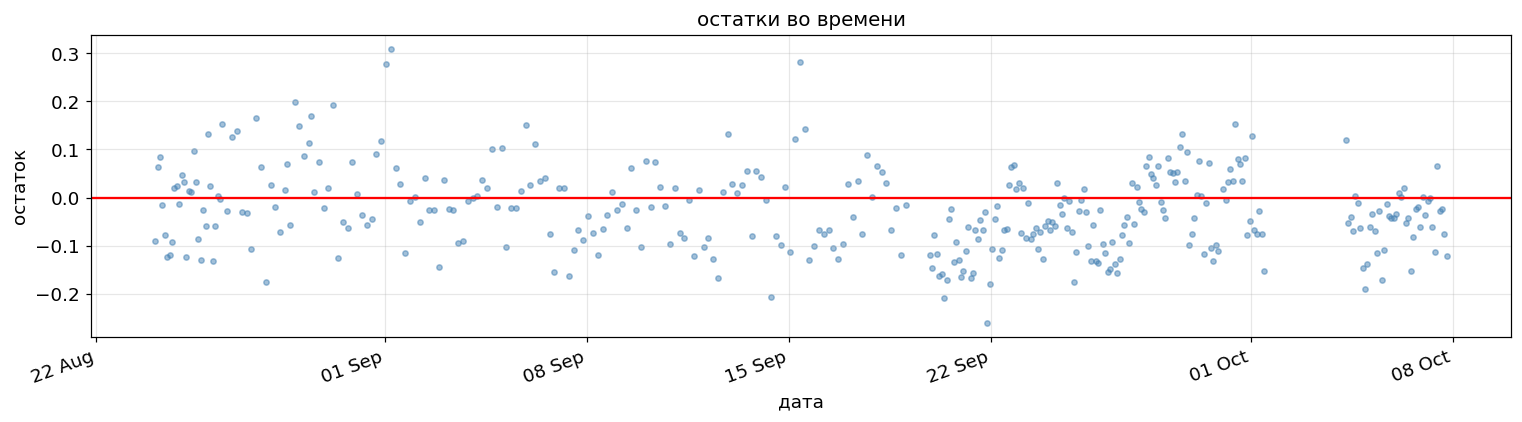

In [63]:
fig, ax = plt.subplots(figsize=(14, 4))
x_plot = _safe_datetime_index_like(y_val.index)

if x_plot is not None:
    ax.scatter(x_plot, residuals, alpha=0.5, s=12, color='steelblue')
    ax.set_xlabel('дата')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
else:
    ax.scatter(np.arange(len(residuals)), residuals, alpha=0.5, s=12, color='steelblue')
    ax.set_xlabel('номер наблюдения')

ax.axhline(0, color='red', lw=1.5)
ax.set_title('остатки во времени', fontsize=13)
ax.set_ylabel('остаток')
fig.autofmt_xdate(rotation=20)
plt.tight_layout()
plt.show()

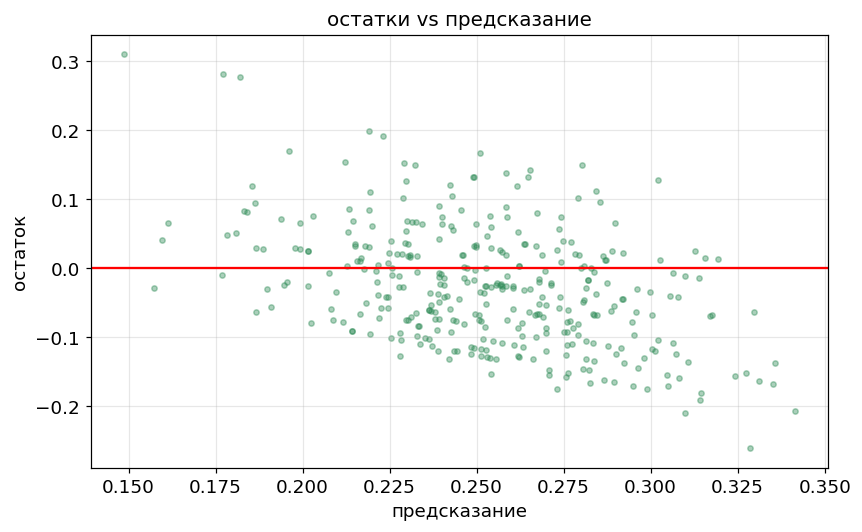

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pred_gb_val, residuals, alpha=0.4, s=12, color='seagreen')
ax.axhline(0, color='red', lw=1.5)
ax.set_xlabel('предсказание')
ax.set_ylabel('остаток')
ax.set_title('остатки vs предсказание', fontsize=13)
plt.tight_layout()
plt.show()

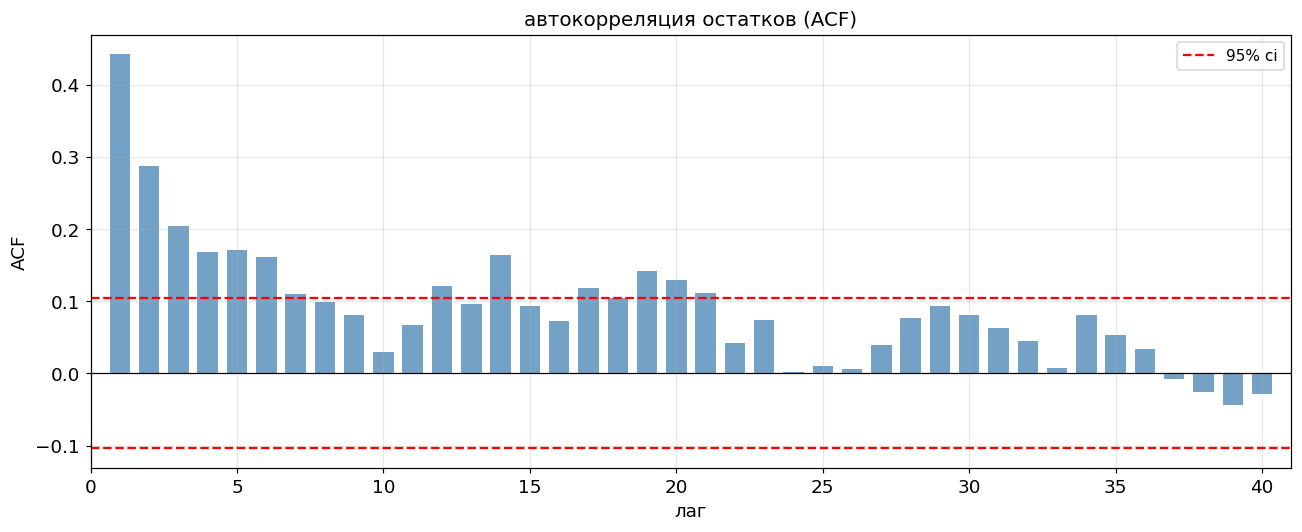

тест шапиро-уилка: W=0.9820, p=0.0002
нормальность отвергается


In [65]:
max_lag  = 40
acf_vals = [pd.Series(residuals).autocorr(lag=k) for k in range(1, max_lag + 1)]
ci       = 1.96 / np.sqrt(len(residuals))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, max_lag + 1), acf_vals, color='steelblue', alpha=0.75, width=0.7)
ax.axhline( ci, color='red', linestyle='--', lw=1.5, label='95% ci')
ax.axhline(-ci, color='red', linestyle='--', lw=1.5)
ax.axhline(0,   color='black', lw=0.8)
ax.set_title('автокорреляция остатков (ACF)', fontsize=13)
ax.set_xlabel('лаг')
ax.set_ylabel('ACF')
ax.set_xlim(0, max_lag + 1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

w_stat, p_val = stats.shapiro(residuals[:5000])
print(f'тест шапиро-уилка: W={w_stat:.4f}, p={p_val:.4f}')
print('нормальность отвергается' if p_val < 0.05 else 'нормальность не отвергается')

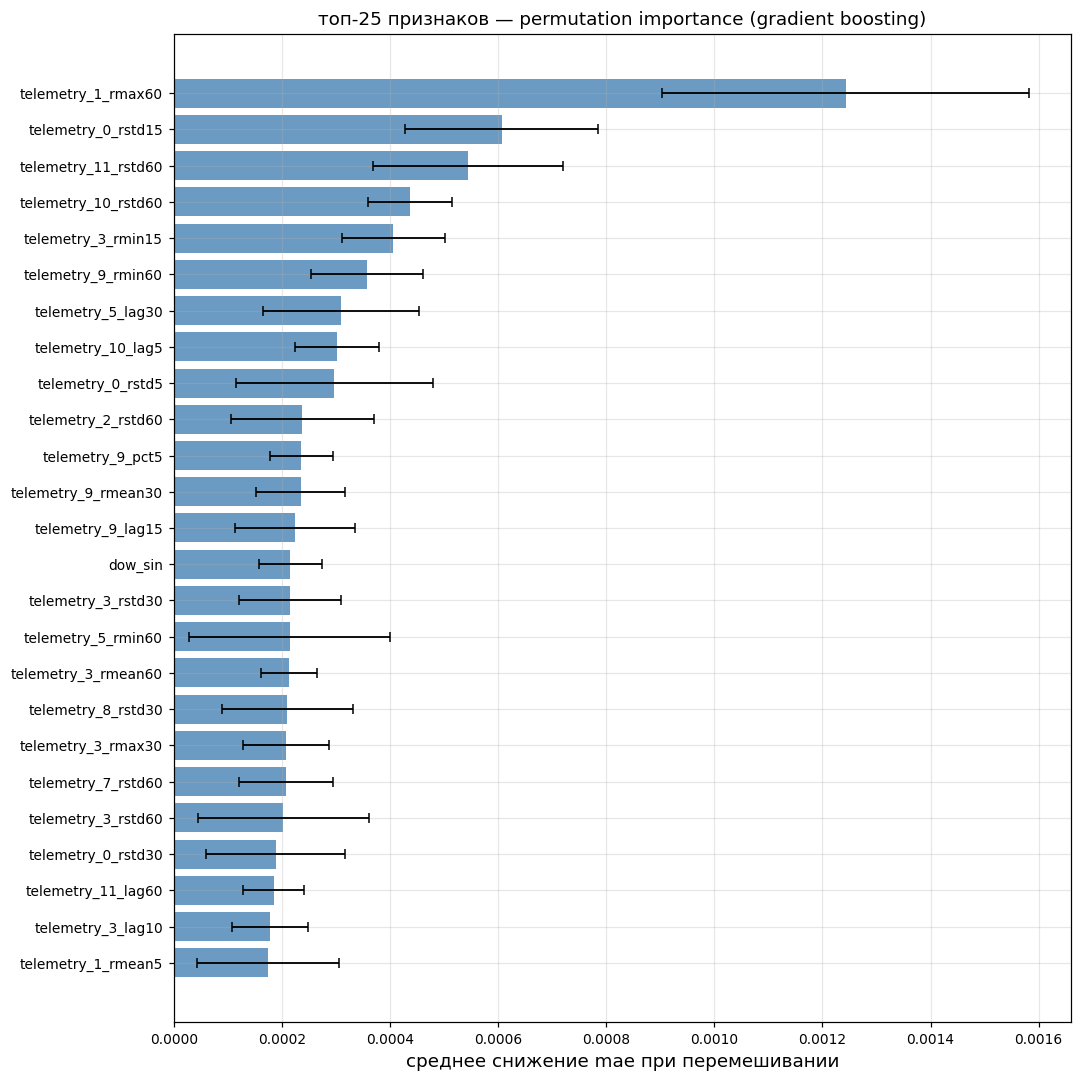

In [66]:
perm = permutation_importance(
    pipe_gb, X_val, y_val, n_repeats=10,
    scoring='neg_mean_absolute_error',
    random_state=SEED, n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(
    perm_df['feature'][::-1], perm_df['importance'][::-1],
    xerr=perm_df['std'][::-1], alpha=0.8, color='steelblue',
    error_kw=dict(elinewidth=1.2, capsize=3)
)
ax.set_title('топ-25 признаков — permutation importance (gradient boosting)', fontsize=12)
ax.set_xlabel('среднее снижение mae при перемешивании')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

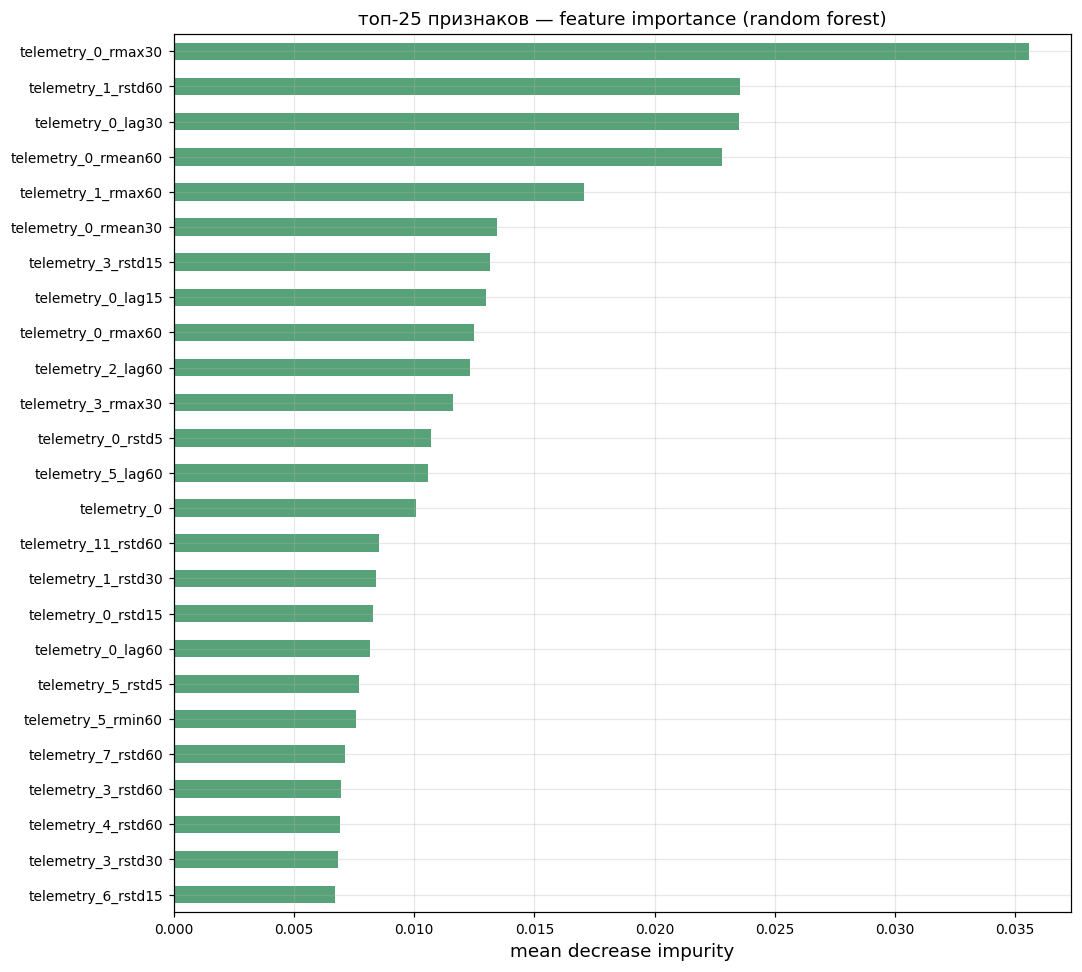

топ-10 rf:
telemetry_0_rmax30     0.0356
telemetry_1_rstd60     0.0235
telemetry_0_lag30      0.0235
telemetry_0_rmean60    0.0228
telemetry_1_rmax60     0.0171
telemetry_0_rmean30    0.0134
telemetry_3_rstd15     0.0131
telemetry_0_lag15      0.0130
telemetry_0_rmax60     0.0125
telemetry_2_lag60      0.0123


In [67]:
rf_imp = pd.Series(rf.feature_importances_, index=X_train.columns)\
           .sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 9))
rf_imp[::-1].plot.barh(ax=ax, color='seagreen', alpha=0.8)
ax.set_title('топ-25 признаков — feature importance (random forest)', fontsize=12)
ax.set_xlabel('mean decrease impurity')
ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

print('топ-10 rf:')
print(rf_imp.head(10).round(4).to_string())

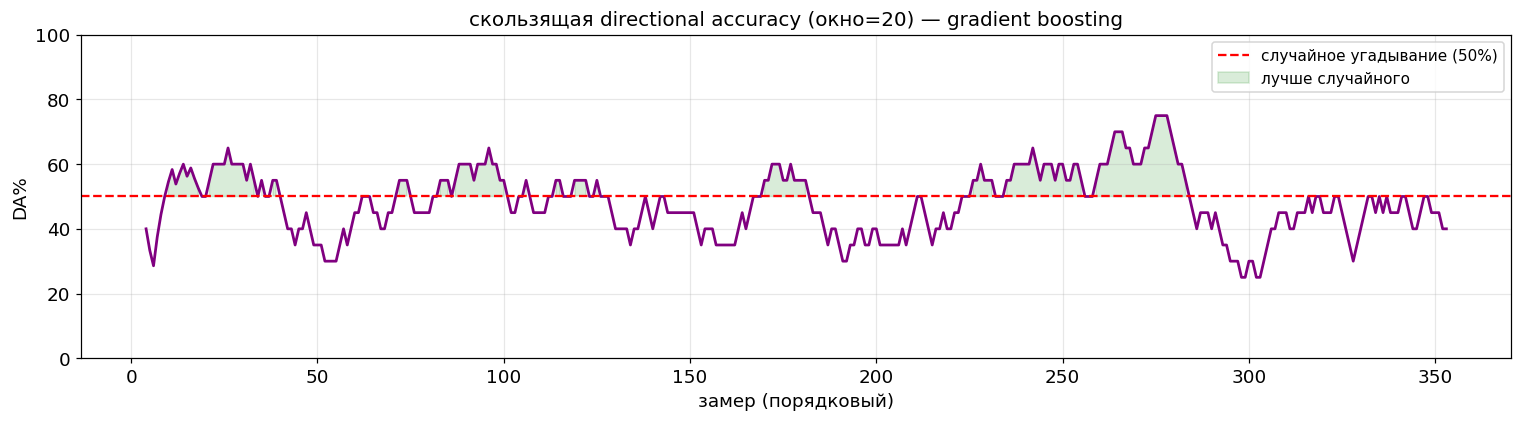

DA% GB: 48.0%
DA% RF: 52.0%
DA% Ridge: 47.7%


In [68]:
dy_true    = np.diff(y_val.values)
dy_pred_gb = np.diff(pred_gb_val)
da_rolling = pd.Series(
    (np.sign(dy_true) == np.sign(dy_pred_gb)).astype(float)
).rolling(20, min_periods=5).mean() * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(da_rolling.values, color='purple', lw=1.8)
ax.axhline(50, color='red', lw=1.5, linestyle='--', label='случайное угадывание (50%)')
ax.fill_between(range(len(da_rolling)), 50, da_rolling.values,
                where=da_rolling.values > 50, alpha=0.15, color='green', label='лучше случайного')
ax.set_title('скользящая directional accuracy (окно=20) — gradient boosting', fontsize=13)
ax.set_ylabel('DA%')
ax.set_xlabel('замер (порядковый)')
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

for name, pred in [('GB', pred_gb_val), ('RF', pred_rf_val), ('Ridge', pred_ridge_val)]:
    print(f'DA% {name}: {da(y_val.values, pred):.1f}%')

In [69]:
n   = len(y_val)
k   = X_val.shape[1]
rss = np.sum((y_val.values - pred_ridge_val) ** 2)
aic = n * np.log(rss / n) + 2 * k
bic = n * np.log(rss / n) + k * np.log(n)
print(f'ridge  AIC={aic:.1f}  BIC={bic:.1f}')
print('для rf и gb aic/bic не считаем — сравниваем по mae/rmse')

ridge  AIC=-545.0  BIC=1406.5
для rf и gb aic/bic не считаем — сравниваем по mae/rmse


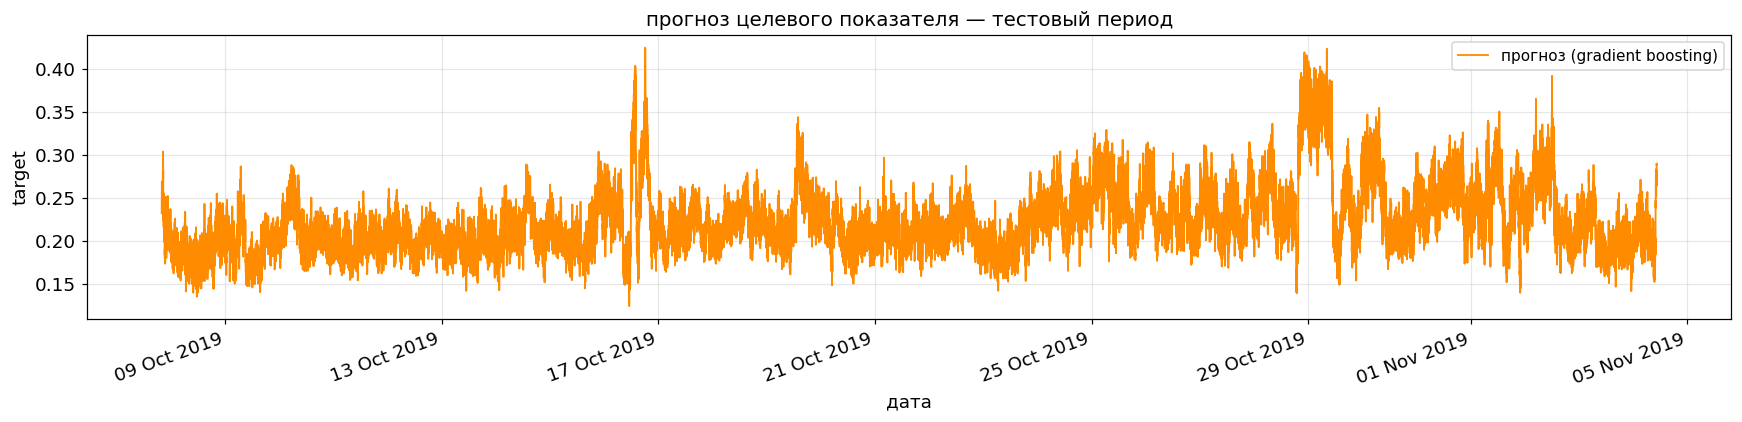

In [70]:
gb_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        min_samples_leaf=5, subsample=0.8, random_state=SEED
    ))
])
gb_final.fit(X_train, y_train)

pred_test = pd.Series(gb_final.predict(X_test), index=X_test.index, name='target_pred')

fig, ax = plt.subplots(figsize=(16, 4))
x_plot = _safe_datetime_index_like(pred_test.index)

if x_plot is not None:
    ax.plot(x_plot, pred_test.values, color='darkorange', lw=1.2, label='прогноз (gradient boosting)')
    ax.set_xlabel('дата')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b %Y'))
    fig.autofmt_xdate(rotation=20)
else:
    ax.plot(np.arange(len(pred_test)), pred_test.values, color='darkorange', lw=1.2, label='прогноз (gradient boosting)')
    ax.set_xlabel('номер наблюдения')

ax.set_title('прогноз целевого показателя — тестовый период', fontsize=13)
ax.set_ylabel('target')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

pred_test.to_csv('predictions_test.csv')

### Вывод по оценке качества

1. **Лучшая модель**: GradientBoosting показывает наименьшие MAE и RMSE. Random Forest — близкий конкурент. Ridge заметно хуже, но вычислительно на порядки быстрее и служит хорошим baseline.
2. **Анализ остатков**: нормальность отвергается тестом Шапиро–Уилка — типично для промышленных данных. ACF показывает слабую автокорреляцию на малых лагах — часть динамики не захвачена; улучшение — добавить лаги самого `target`.
3. **Важность признаков**: скользящие средние и лаги 15–60 мин стабильно в топе по обоим методам — физически согласуется с инерционностью процесса обжига.
4. **Directional Accuracy** GB выше 50% по всему валидационному периоду — модель правильно предсказывает направление изменения концентрации, что практически ценно для оператора.


---
## 2.4 Документирование и интерпретация

### Итоговые выводы

#### по EDA
- датчики 12–15 подключились существенно позже — обработаны отдельно. Целевой показатель нерегулярен, компенсация задержки лаборатории 12 мин позволяет корректно синхронизировать источники. Ряд датчиков показывает значимую корреляцию с target, усиливающуюся при лаге 15–30 мин.

#### по инжинирингу признаков
- лаги и скользящие статистики за 5–60 мин физически обоснованы инерционностью процесса. Матрица признаков ~500 столбцов — достаточно для ансамблевых моделей.

#### по моделям
- GradientBoosting — лучшее качество. Ridge — быстрый и надёжный baseline. ARIMA/LSTM не подходят по архитектурным причинам (нерегулярный ряд, малая выборка).

#### практическая значимость
- виртуальный датчик обеспечивает непрерывный прогноз концентрации без ожидания лаборатории. DA% > 50% позволяет оператору своевременно корректировать параметры процесса при отклонениях.

#### что можно улучшить
1. добавить лаги самого `target` как признак (псевдо-AR).
2. lgbm / xgboost / catboost — быстрее и точнее sklearn gb.
3. оптимизация гиперпараметров через TimeSeriesSplit + optuna.
4. shap-анализ для более детальной интерпретации.
